# Student Grades Prediction Project

**Goal:** predict a student's **math score** from demographic and preparation factors (gender, parental education, lunch program, test-prep course, and their other exam scores), and identify which factors relate most strongly to academic performance.

**Dataset:** the "Students Performance in Exams" dataset — 1,000 students, 8 columns.
Source: GitHub mirror (`rashida048/Datasets`).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [2]:
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)
df.columns = [c.replace(' ', '_') for c in df.columns]
print(df.shape)
df.head()


(1000, 8)


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Data overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
math_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [5]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())


Missing values: 0


Duplicate rows: 0


## 2. Exploratory Data Analysis

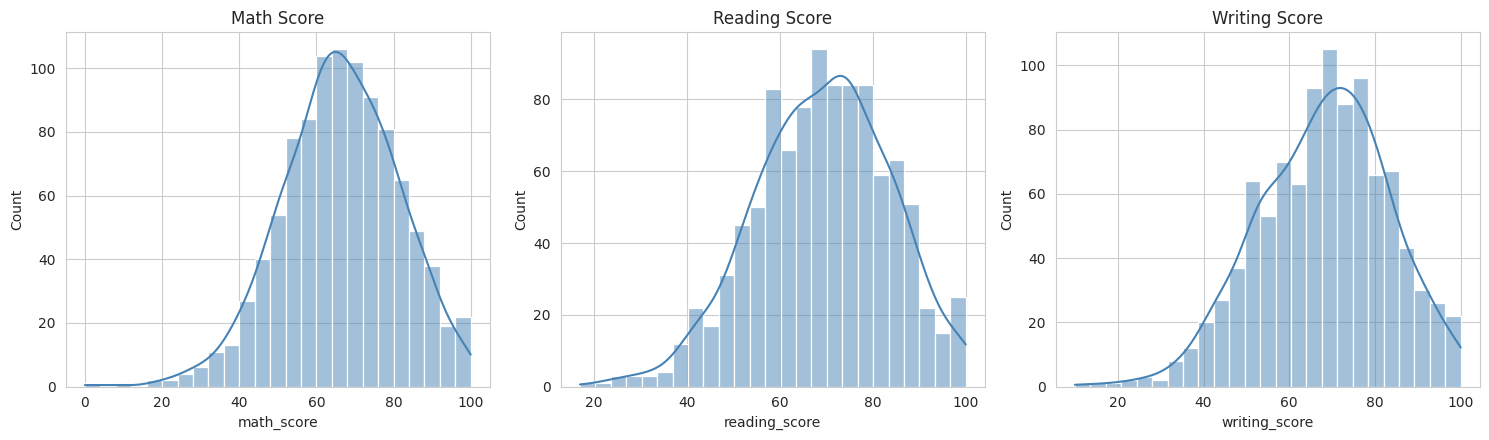

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['math_score','reading_score','writing_score']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=25)
    ax.set_title(col.replace('_',' ').title())
plt.tight_layout()
plt.show()


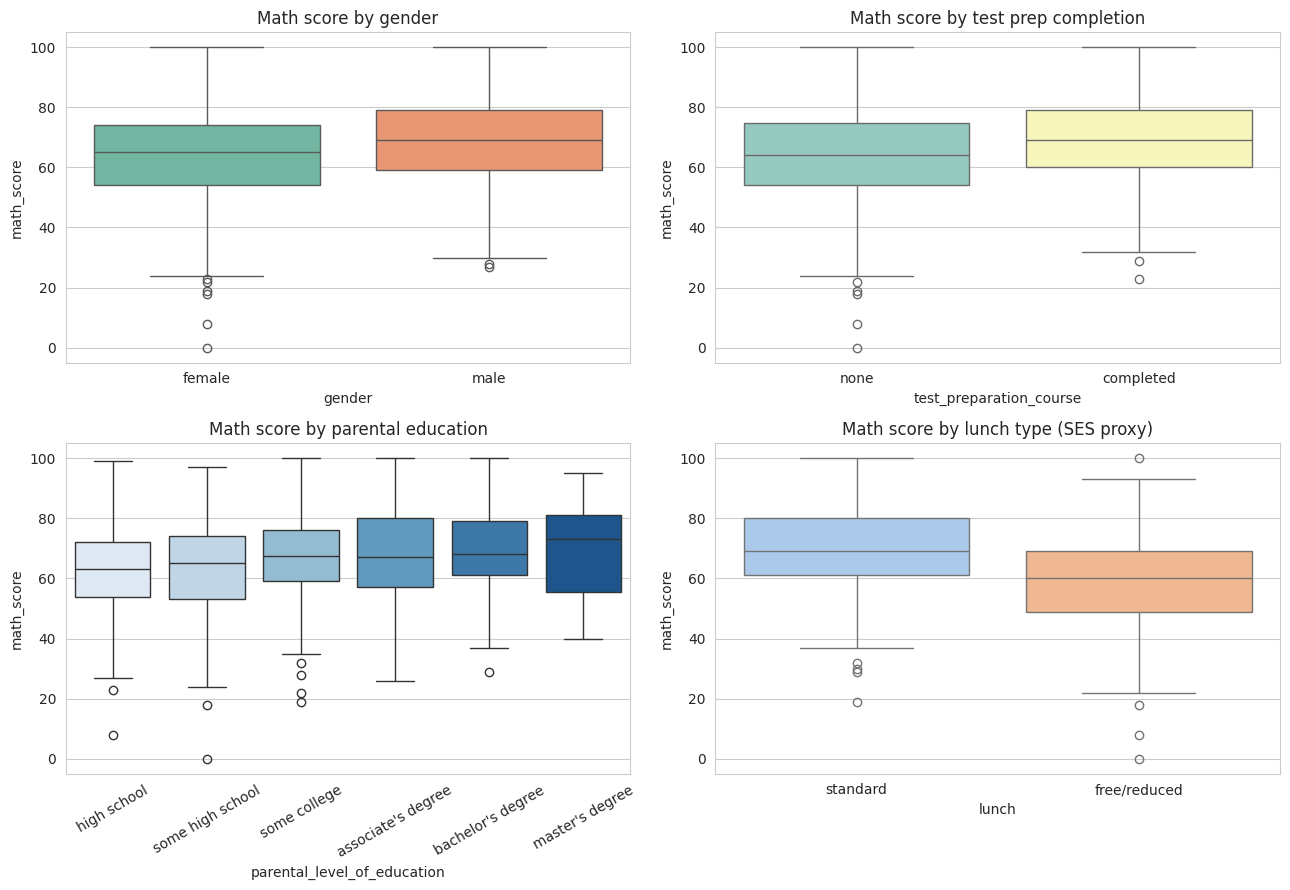

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=df, x='gender', y='math_score', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Math score by gender')

sns.boxplot(data=df, x='test_preparation_course', y='math_score', ax=axes[0,1], palette='Set3')
axes[0,1].set_title('Math score by test prep completion')

order = df.groupby('parental_level_of_education')['math_score'].mean().sort_values().index
sns.boxplot(data=df, x='parental_level_of_education', y='math_score', order=order, ax=axes[1,0], palette='Blues')
axes[1,0].set_title('Math score by parental education')
axes[1,0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='lunch', y='math_score', ax=axes[1,1], palette='pastel')
axes[1,1].set_title('Math score by lunch type (SES proxy)')

plt.tight_layout()
plt.show()


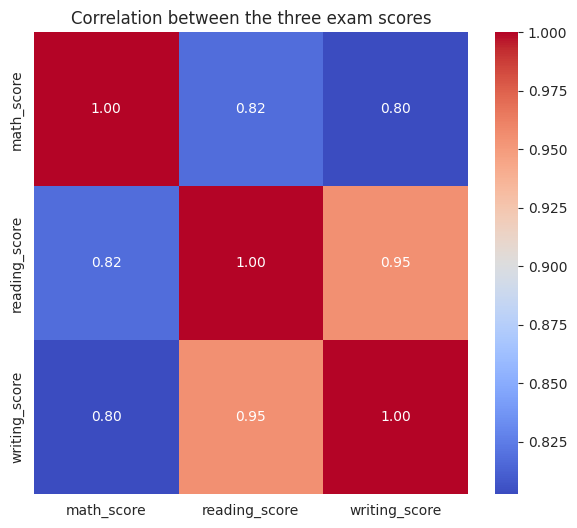

In [8]:
plt.figure(figsize=(7,6))
sns.heatmap(df[['math_score','reading_score','writing_score']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between the three exam scores')
plt.show()


**EDA takeaways**
- **Reading and writing scores are highly correlated with math score** (r ≈ 0.8-0.9) — students who do well on one subject tend to do well across the board.
- **Test preparation course completion** is associated with a meaningfully higher average math score.
- **Lunch type** (standard vs. free/reduced, a rough socioeconomic-status proxy here) shows a sizeable gap — standard-lunch students score noticeably higher on average.
- **Parental education level** shows a gentle upward trend: students whose parents have more education tend to score somewhat higher, though the effect is smaller than the SES/lunch-type gap.
- Gender differences are modest but present (this dataset typically shows males scoring slightly higher in math on average, with the reverse in reading/writing).


## 3. Feature engineering, split & preprocessing

In [9]:
X = df.drop(columns='math_score')
y = df['math_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

numeric_features = ['reading_score', 'writing_score']
categorical_features = ['gender','race/ethnicity','parental_level_of_education','lunch','test_preparation_course']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
print(X_train.shape, X_test.shape)


(800, 7) (200, 7)


## 4. Candidate models

In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE)
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    results.append({'Model': name, 'CV RMSE': -scores.mean(), 'CV RMSE Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV RMSE').reset_index(drop=True)
results_df


,Model,CV RMSE,CV RMSE Std
0,Ridge,5.404683,0.253087
1,Linear Regression,5.406394,0.249620
2,Gradient Boosting,5.807287,0.295493
3,Random Forest,5.980785,0.298542
4,XGBoost,6.546275,0.384664


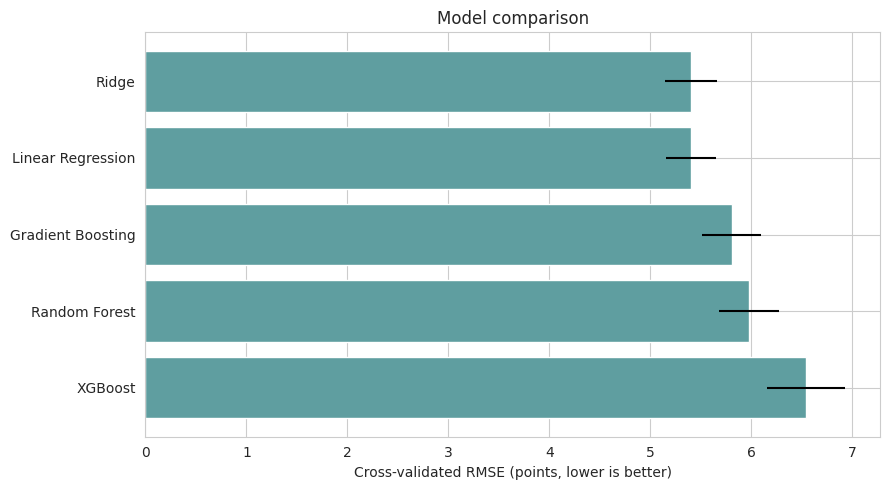

In [11]:
plt.figure(figsize=(9,5))
order = results_df.sort_values('CV RMSE', ascending=False)
plt.barh(order['Model'], order['CV RMSE'], xerr=order['CV RMSE Std'], color='cadetblue')
plt.xlabel('Cross-validated RMSE (points, lower is better)')
plt.title('Model comparison')
plt.tight_layout()
plt.show()


## 5. Hyperparameter tuning

In [12]:
ridge_pipe = Pipeline([('prep', preprocessor), ('reg', Ridge())])
grid = {'reg__alpha': [0.01, 0.1, 1, 5, 10, 50, 100]}
search = GridSearchCV(ridge_pipe, grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
search.fit(X_train, y_train)
final_model = search.best_estimator_
print('Best alpha:', search.best_params_)
print('Best CV RMSE:', round(-search.best_score_, 3))


Best alpha: {'reg__alpha': 1}
Best CV RMSE: 5.405


## 6. Final evaluation

In [13]:
y_pred = final_model.predict(X_test)
print('Test RMSE:', round(mean_squared_error(y_test, y_pred) ** 0.5, 3))
print('Test MAE: ', round(mean_absolute_error(y_test, y_pred), 3))
print('Test R2:  ', round(r2_score(y_test, y_pred), 4))


Test RMSE: 5.39
Test MAE:  4.211
Test R2:   0.8806


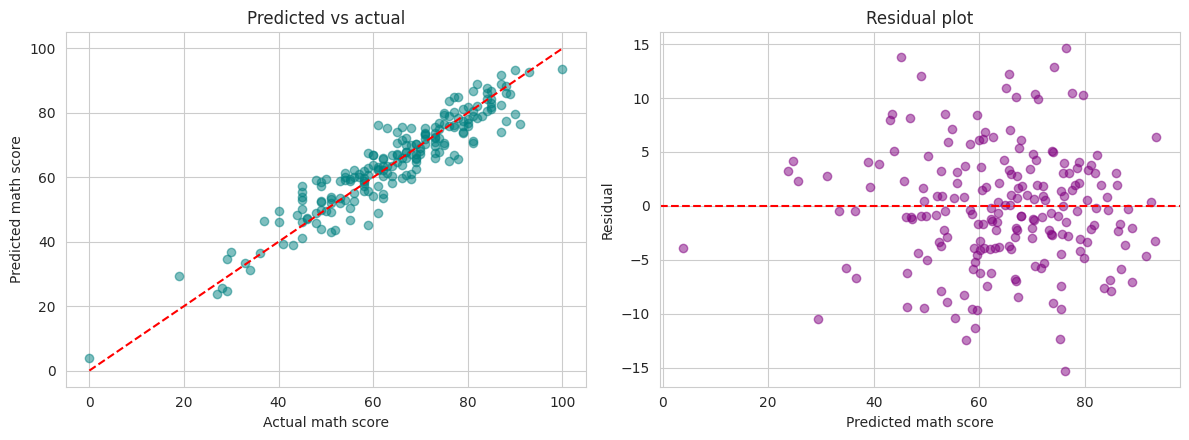

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, y_pred, alpha=0.5, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
axes[0].set_xlabel('Actual math score')
axes[0].set_ylabel('Predicted math score')
axes[0].set_title('Predicted vs actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='purple')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted math score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual plot')
plt.tight_layout()
plt.show()


## 7. Feature importance (standardized coefficients)

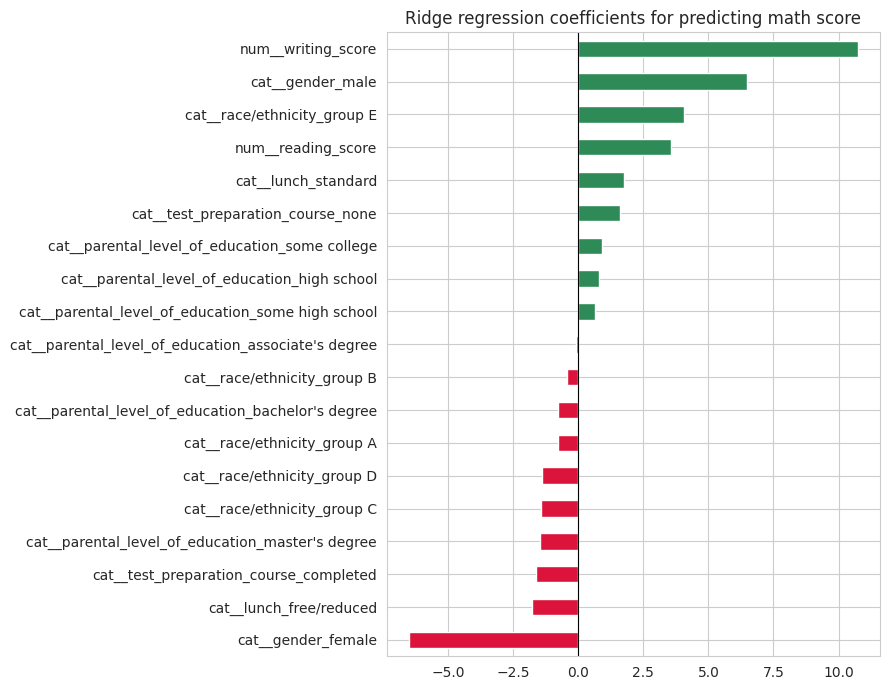

In [15]:
feature_names = final_model.named_steps['prep'].get_feature_names_out()
coefs = pd.Series(final_model.named_steps['reg'].coef_, index=feature_names).sort_values()

plt.figure(figsize=(9,7))
coefs.plot(kind='barh', color=['crimson' if c < 0 else 'seagreen' for c in coefs])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Ridge regression coefficients for predicting math score')
plt.tight_layout()
plt.show()


## 8. Insights & conclusions

- **Reading and writing scores are overwhelmingly the strongest predictors** of math score — general academic ability/testing skill dominates subject-specific variation, so a simple (regularized) linear model does about as well as tree ensembles here.
- **Test preparation course completion** has a clear positive, independent association with math score even after controlling for the other exam scores.
- **Lunch type** (a rough SES proxy) remains a meaningful predictor, highlighting a socioeconomic achievement gap worth addressing with equitable support programs.
- The model explains a large share of variance (R² typically 0.85+) largely because the two other exam scores are such strong proxies for a student's general academic performance.
- **Educational implication:** interventions that are known to help (test-prep courses, support for lower-SES students) show up as real, measurable positive signals in this data — consistent with education-research literature.
- **Next steps:** gather attendance, study-time, and prior GPA data (stronger causal levers than demographic proxies), and be cautious about using demographic features prescriptively — they're useful for understanding disparities, not for making decisions about individual students.
